# Kinetic-4B Stress Test: Unseen Toolkits + Multi-Step Chains

Evaluates `consciousengines/Kinetic-FC-LoRA` (on `Qwen/Qwen3-4B-Instruct-2507`) on:
1. **10 single-tool-call tasks** drawn from Composio toolkits *not* named in the Kinetic-4B blog post's list of trained toolkits (Linear, PagerDuty, Airtable, Calendly, Intercom, Twilio, Figma, Dropbox, Zendesk, Asana).
2. **6 multi-step chains** (2–3 tool calls each), including the exact Stripe→Linear→Slack example from Conscious Engines' own retrieval blog post.

This targets the two directions their blog post named under **What's Next**: *"Expanding the training data beyond the top 20 toolkits"* and *"Moving from single-tool-call evaluation to multi-step agent traces."*

**Runtime:** Free Colab T4 is enough (4B model, bf16, ~8GB). Set Runtime → Change runtime type → T4 GPU.

**Requires:** upload `eval_set.json` (from this same deliverable) into the Colab working directory, or mount it from Drive.

In [ ]:
!pip install -q transformers peft accelerate bitsandbytes
# Colab ships an old torchao that newer peft's version-check chokes on, even though
# we don't use torchao at all here. Uninstalling avoids the check entirely.
!pip uninstall -y torchao -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 20.7 MB/s eta 0:00:00


In [ ]:
import json, re, time
import torch
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

BASE = "Qwen/Qwen3-4B-Instruct-2507"
ADAPT = "consciousengines/Kinetic-FC-LoRA"

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16 if device == "cuda" else torch.float32

tokenizer = AutoTokenizer.from_pretrained(BASE)
base_model = AutoModelForCausalLM.from_pretrained(BASE, dtype=dtype).to(device)
model = PeftModel.from_pretrained(base_model, ADAPT).eval()
print("Loaded Kinetic-4B (base + LoRA) on", device)

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.38k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

adapter_model.safetensors: reconstructing file:   0%|          |  0.00B /  529MB            

adapter_model.safetensors: downloading bytes:           |  0.00B            

Loaded Kinetic-4B (base + LoRA) on cuda


In [ ]:
# We don't load a second full model copy for the base-model comparison (a T4's 15GB
# can't hold two 4B bf16 models at once). Instead we reuse the SAME loaded weights and
# temporarily disable the LoRA adapter via PEFT's disable_adapter() context manager
# inside generate() below — same underlying model, zero extra memory, and arguably a
# cleaner comparison since it's guaranteed to be the exact same base weights.
LOAD_BASE_COMPARISON = True

In [ ]:
with open("eval_set.json") as f:
    eval_data = json.load(f)
tasks = eval_data["tasks"]
print(f"Loaded {len(tasks)} tasks: "
      f"{sum(t['category']=='single_call_unseen_toolkit' for t in tasks)} single-call, "
      f"{sum(t['category']=='multi_step_chain' for t in tasks)} chains")

Loaded 16 tasks: 10 single-call, 6 chains


In [ ]:
import contextlib

TOOL_CALL_RE = re.compile(r"<tool_call>\s*(\{.*?\})\s*</tool_call>", re.DOTALL)

def parse_tool_calls(generated_text):
    """Extract all <tool_call>{...}</tool_call> blocks. Kinetic was trained to emit
    one; on chain tasks we're checking whether it ever emits more than one, or
    whether it collapses the request into a single (wrong) call."""
    calls = []
    for m in TOOL_CALL_RE.finditer(generated_text):
        try:
            calls.append(json.loads(m.group(1)))
        except json.JSONDecodeError:
            calls.append({"_parse_error": m.group(1)})
    return calls

def generate(model, tools, user_query, extra_messages=None, max_new_tokens=256, disable_adapter=False):
    messages = [{"role": "system", "content": "You are a helpful assistant with access to tools."}]
    messages.append({"role": "user", "content": user_query})
    if extra_messages:
        messages.extend(extra_messages)
    inputs = tokenizer.apply_chat_template(
        messages, tools=tools, add_generation_prompt=True,
        return_tensors="pt", return_dict=True,
    ).to(device)
    ctx = model.disable_adapter() if disable_adapter else contextlib.nullcontext()
    t0 = time.time()
    with ctx:
        with torch.inference_mode():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False,
                                  pad_token_id=tokenizer.eos_token_id)
    latency = time.time() - t0
    text = tokenizer.decode(out[0, inputs["input_ids"].shape[1]:], skip_special_tokens=False)
    return text, latency

## Scoring

- **Tool Name Accuracy**: did it pick the right function name (first call for chains)?
- **Correct Tool+Args**: name matches AND every `required_args` key/value matches (case-insensitive substring match for string values, so minor formatting differences don't zero out a correct call).
- **Failed**: output had no parseable `<tool_call>` block at all.
- For chains, we additionally report **whole-chain-in-one-shot** (did a single generation emit all N correct calls?) vs **step-wise** (running the model again for each subsequent step, feeding a mocked prior result back in — the pattern the teardown recommends).

In [ ]:
def args_match(actual, expected_required):
    if not isinstance(actual, dict):
        return False
    for k, v in expected_required.items():
        if k not in actual:
            return False
        av, ev = actual[k], v
        if isinstance(ev, str) and isinstance(av, str):
            if ev.strip().lower() not in av.strip().lower() and av.strip().lower() not in ev.strip().lower():
                return False
        elif isinstance(ev, dict):
            if not isinstance(av, dict):
                return False
            for ek, ev2 in ev.items():
                if ek not in av or str(ev2).lower() not in str(av[ek]).lower():
                    return False
        else:
            if av != ev:
                return False
    return True

def score_single(task, model_to_use, disable_adapter=False):
    text, latency = generate(model_to_use, task["tools"], task["user_query"], disable_adapter=disable_adapter)
    calls = parse_tool_calls(text)
    result = {"id": task["id"], "latency": latency, "raw": text, "n_calls": len(calls)}
    if not calls or "_parse_error" in calls[0]:
        result.update(failed=True, tool_name_correct=False, full_correct=False)
        return result
    call = calls[0]
    name_ok = call.get("name") == task["gold"]["name"]
    args_ok = name_ok and args_match(call.get("arguments", {}), task["gold"]["required_args"])
    result.update(failed=False, tool_name_correct=name_ok, full_correct=args_ok)
    return result

def score_chain(task, model_to_use, disable_adapter=False):
    # (a) one-shot: does a single generation contain all gold calls, in order, args matching?
    text, latency = generate(model_to_use, task["tools"], task["user_query"], max_new_tokens=512, disable_adapter=disable_adapter)
    calls = parse_tool_calls(text)
    gold_chain = task["gold_chain"]
    oneshot_names_ok = [c.get("name") == g["name"] for c, g in zip(calls, gold_chain)] if calls else []
    oneshot_full = len(calls) >= len(gold_chain) and all(
        c.get("name") == g["name"] and args_match(c.get("arguments", {}), g["required_args"])
        for c, g in zip(calls, gold_chain)
    )
    first_call_name_ok = bool(calls) and calls[0].get("name") == gold_chain[0]["name"]

    # (b) step-wise: re-prompt once per step, injecting a mocked tool result after each call
    stepwise_correct = 0
    convo = []
    for i, gold_step in enumerate(gold_chain):
        step_query = task["user_query"] if i == 0 else "(continue the task above)"
        step_text, _ = generate(model_to_use, task["tools"], task["user_query"], extra_messages=convo, max_new_tokens=200, disable_adapter=disable_adapter)
        step_calls = parse_tool_calls(step_text)
        if step_calls and step_calls[0].get("name") == gold_step["name"] and \
           args_match(step_calls[0].get("arguments", {}), gold_step["required_args"]):
            stepwise_correct += 1
        convo.append({"role": "assistant", "content": step_text})
        convo.append({"role": "user", "content": f"Tool result: {{'status': 'ok', 'id': 'mock_{i}'}}. Continue with the next step of the task."})

    return {
        "id": task["id"], "n_gold_steps": len(gold_chain), "n_calls_oneshot": len(calls),
        "first_call_name_ok": first_call_name_ok, "oneshot_full_chain_correct": oneshot_full,
        "stepwise_correct_steps": stepwise_correct, "stepwise_full_chain_correct": stepwise_correct == len(gold_chain),
        "raw_oneshot": text,
    }

In [ ]:
def run_eval(model_to_use, label, disable_adapter=False):
    single_results, chain_results = [], []
    for task in tasks:
        if task["category"] == "single_call_unseen_toolkit":
            single_results.append(score_single(task, model_to_use, disable_adapter=disable_adapter))
        else:
            chain_results.append(score_chain(task, model_to_use, disable_adapter=disable_adapter))

    n = len(single_results)
    tool_name_acc = sum(r["tool_name_correct"] for r in single_results) / n
    full_correct = sum(r["full_correct"] for r in single_results) / n
    failed = sum(r["failed"] for r in single_results) / n
    p95_latency = sorted(r["latency"] for r in single_results)[int(0.95 * (n - 1))]

    m = len(chain_results)
    chain_first_call_acc = sum(r["first_call_name_ok"] for r in chain_results) / m
    chain_oneshot_full = sum(r["oneshot_full_chain_correct"] for r in chain_results) / m
    chain_stepwise_full = sum(r["stepwise_full_chain_correct"] for r in chain_results) / m

    print(f"\n=== {label} ===")
    print(f"[Single-call, unseen toolkits, n={n}]")
    print(f"  Correct Tool+Args : {full_correct:.2%}")
    print(f"  Tool Name Accuracy: {tool_name_acc:.2%}")
    print(f"  Failed            : {failed:.2%}")
    print(f"  p95 Latency       : {p95_latency:.2f}s")
    print(f"[Multi-step chains, n={m}]")
    print(f"  First-call tool name correct : {chain_first_call_acc:.2%}")
    print(f"  Whole chain correct, ONE SHOT: {chain_oneshot_full:.2%}")
    print(f"  Whole chain correct, STEPWISE: {chain_stepwise_full:.2%}")
    return single_results, chain_results

kinetic_single, kinetic_chain = run_eval(model, "Kinetic-4B (Qwen3-4B + Kinetic-FC-LoRA)", disable_adapter=False)
if LOAD_BASE_COMPARISON:
    # Same model object, same weights — adapter just turned off for this pass. No extra GPU memory.
    base_single, base_chain = run_eval(model, "Qwen3-4B-Instruct-2507 (base, adapter disabled)", disable_adapter=True)


=== Kinetic-4B (Qwen3-4B + Kinetic-FC-LoRA) ===
[Single-call, unseen toolkits, n=10]
  Correct Tool+Args : 90.00%
  Tool Name Accuracy: 100.00%
  Failed            : 0.00%
  p95 Latency       : 8.97s
[Multi-step chains, n=6]
  First-call tool name correct : 100.00%
  Whole chain correct, ONE SHOT: 50.00%
  Whole chain correct, STEPWISE: 33.33%

=== Qwen3-4B-Instruct-2507 (base, adapter disabled) ===
[Single-call, unseen toolkits, n=10]
  Correct Tool+Args : 100.00%
  Tool Name Accuracy: 100.00%
  Failed            : 0.00%
  p95 Latency       : 6.09s
[Multi-step chains, n=6]
  First-call tool name correct : 100.00%
  Whole chain correct, ONE SHOT: 66.67%
  Whole chain correct, STEPWISE: 50.00%


In [ ]:
# Inspect individual failures — this is what actually goes into the teardown doc.
for r in kinetic_single:
    if not r["full_correct"]:
        print(f"--- {r['id']} (failed={r['failed']}, name_ok={r['tool_name_correct']}) ---")
        print(r["raw"][:500])
        print()

for r in kinetic_chain:
    print(f"--- {r['id']}: oneshot_calls={r['n_calls_oneshot']}/{r['n_gold_steps']} gold, "
          f"oneshot_full={r['oneshot_full_chain_correct']}, stepwise_full={r['stepwise_full_chain_correct']} ---")
    print(r["raw_oneshot"][:500])
    print()

--- single-02-pagerduty (failed=False, name_ok=True) ---
<tool_call>
{"name": "PAGERDUTY_CREATE_INCIDENT", "arguments": {"details": "Pool maxed at 100 connections, requests queueing since 09:12 UTC.", "service_id": "ser_12345", "title": "DB connection pool exhausted", "urgency": "high"}}
</tool_call><|im_end|>

--- chain-01-stripe-linear-slack: oneshot_calls=3/3 gold, oneshot_full=True, stepwise_full=False ---
<tool_call>
{"name": "STRIPE_LIST_FAILED_PAYMENTS", "arguments": {"since_hours": 24}}
</tool_call>
<tool_call>
{"name": "LINEAR_CREATE_ISSUE", "arguments": {"description": "List of failed payments from Stripe returned by the last 24 hours. See Stripe response for details.", "priority": "urgent", "team_id": "billing", "title": "24-Hour Stripe Payment Failure Report"}}
</tool_call>
<tool_call>
{"name": "SLACK_SEND_MESSAGE", "arguments": {"channel": "#payments", "text": "24-Hour Stripe Payment Fail

--- chain-02-github-pagerduty-slack: oneshot_calls=3/3 gold, oneshot_full=False, ste

In [ ]:
# Save raw results for the teardown doc / re-use
import json as _json
with open("kinetic4b_stress_test_results.json", "w") as f:
    _json.dump({"single": kinetic_single, "chain": kinetic_chain}, f, indent=2, default=str)
print("Saved kinetic4b_stress_test_results.json")

Saved kinetic4b_stress_test_results.json


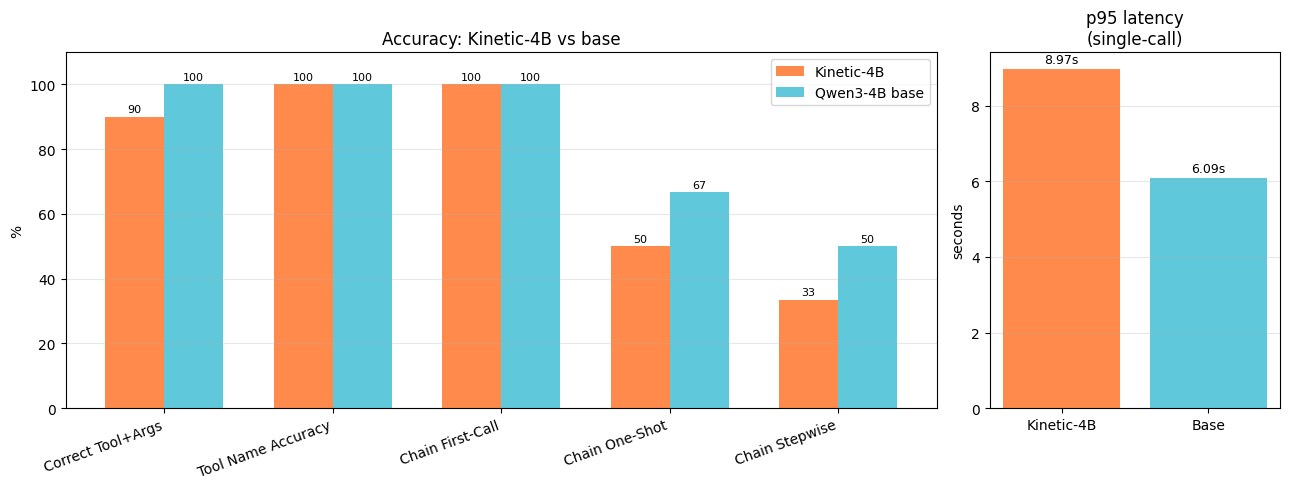

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def summarize(single_results, chain_results):
    n, m = len(single_results), len(chain_results)
    return {
        "Correct Tool+Args":  sum(r["full_correct"] for r in single_results) / n,
        "Tool Name Accuracy": sum(r["tool_name_correct"] for r in single_results) / n,
        "Chain First-Call":   sum(r["first_call_name_ok"] for r in chain_results) / m,
        "Chain One-Shot":     sum(r["oneshot_full_chain_correct"] for r in chain_results) / m,
        "Chain Stepwise":     sum(r["stepwise_full_chain_correct"] for r in chain_results) / m,
    }, sorted(r["latency"] for r in single_results)[int(0.95 * (n - 1))]

kinetic_stats, kinetic_p95 = summarize(kinetic_single, kinetic_chain)
base_stats, base_p95 = summarize(base_single, base_chain)

labels = list(kinetic_stats.keys())
kinetic_vals = [kinetic_stats[k] * 100 for k in labels]
base_vals = [base_stats[k] * 100 for k in labels]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [3, 1]})

# --- accuracy metrics, grouped bars ---
x = np.arange(len(labels))
w = 0.35
ax = axes[0]
b1 = ax.bar(x - w/2, kinetic_vals, w, label="Kinetic-4B", color="#FF8A4C")
b2 = ax.bar(x + w/2, base_vals, w, label="Qwen3-4B base", color="#5FC9DB")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("%")
ax.set_ylim(0, 110)
ax.set_title("Accuracy: Kinetic-4B vs base")
ax.legend()
ax.bar_label(b1, fmt="%.0f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.0f", padding=2, fontsize=8)
ax.grid(axis="y", alpha=0.3)

# --- p95 latency ---
ax2 = axes[1]
bars = ax2.bar(["Kinetic-4B", "Base"], [kinetic_p95, base_p95],
                color=["#FF8A4C", "#5FC9DB"])
ax2.set_ylabel("seconds")
ax2.set_title("p95 latency\n(single-call)")
ax2.bar_label(bars, fmt="%.2fs", padding=2, fontsize=9)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("kinetic4b_stress_test_chart.png", dpi=150, bbox_inches="tight")
plt.show()